## How to download the data from ERDDAP

The data in this notebook comes from BODC's ERDDAP server. ERDDAP lets you choose exactly which variables and dates you want, so you only download what you need.

### Steps

1. **Open the ERDDAP server** at https://linkedsystems.uk/erddap/index.html and find the glider dataset. The dataset used here is `Ziggy_730_R`. You can also reach a dataset from the Deployment Catalogue.

2. **Open the data access form.** On the dataset's page, click the **Data** link. It opens a form with the title "Data Access Form" (a page like `https://linkedsystems.uk/erddap/tabledap/Ziggy_730_R.html`).

3. **Choose the variables.** Tick the variables you want. For this exercise we use:
   - `time`
   - `PRES` (pressure, which we use as a measure of depth)
   - `TEMP` (temperature)

4. **Subset the data.** Under *Constraints*, set a start and end time, for example `2024-05-01` to `2024-05-07`. Dataset files can be huge, so a short date range keeps the download small and the graphs readable.

5. **Choose the file type.** In the file type dropdown, select **.csv**.

6. **Download.** Click **Submit** (or **Download the Data or an Image**). ERDDAP creates a file with an automatically generated name, like `Ziggy_730_R_43a4_74f6_fe30.csv`, and downloads it.

7. **Move the file** into the same folder as this notebook, so `pd.read_csv("your_file.csv")` can find it.

### Tips

- **Line 2 of the file is the units row.** ERDDAP CSV files have the column names on line 1 and the units (for example `UTC`, `dbar`, `degree_C`) on line 2, so we skip that line when loading with pandas (`skiprows=[1]`).
- **Reload the same data later.** The web address ERDDAP builds when you press Submit contains your choices. You can copy it, change the extension to `.csv`, and pass it straight to `pd.read_csv(url, skiprows=[1])` with no download.
- **Very large file?** Narrow the date range, or tick fewer variables.

### (Optional) Opening the data in Excel

ERDDAP does not export Excel files, but you can open the `.csv` in Excel and choose **File > Save As > Excel Workbook (.xlsx)**. Remember that row 2 will contain the units.

## READING CSV
Reading the CSV and looking at the summary of dataset

In [18]:
import pandas as pd

# Read the CSV file
df = pd.read_csv("Ziggy_730_R_43a4_74f6_fe30.csv")

print(df.shape)
display(df.head())
print(df.columns.tolist())
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
df.info()


(8694, 44)


,longitude (degrees_east),latitude (degrees_north),AAFDZZ01 (UTBB),AAFDZZ01_QC,CNDC (mhos/m),CNDC_QC,DEPLOYMENT_LATITUDE,DEPLOYMENT_LONGITUDE,DEPLOYMENT_TIME (UTC),ENGINEERING_CYCLE_NUMBER (count),...,SENSOR_WATER_TEMPERATURE_SENSOR_0345,SIGMA_T (kg/m^3),SIGMA_T_QC,TEMP (degree_Celsius),TEMP_QC,time (UTC),TIME_GPS (UTC),TIME_GPS_QC,TRAJECTORY,WMO_IDENTIFIER
0,NaN,NaN,NaN,NaN,NaN,NaN,57.091717,-9.54837,2026-08-24T23:00:00Z,NaN,...,NaN,NaN,NaN,NaN,NaN,2026-08-25T12:40:04Z,2026-08-25T12:40:04Z,0,Ziggy_20260825,830
1,NaN,NaN,NaN,NaN,NaN,NaN,57.091717,-9.54837,2026-08-24T23:00:00Z,NaN,...,NaN,NaN,NaN,NaN,NaN,2026-08-25T12:43:20Z,2026-08-25T12:43:20Z,0,Ziggy_20260825,830
2,-9.548507,57.09186,45843.887,0.0,NaN,0.0,57.091717,-9.54837,2026-08-24T23:00:00Z,0.0,...,NaN,NaN,0.0,14.747421,0.0,2026-08-25T12:44:03Z,2026-08-25T12:44:03Z,0,Ziggy_20260825,830
3,-9.548522,57.09186,45853.863,0.0,NaN,0.0,57.091717,-9.54837,2026-08-24T23:00:00Z,1.0,...,NaN,NaN,0.0,14.747408,0.0,2026-08-25T12:44:13Z,2026-08-25T12:44:13Z,0,Ziggy_20260825,830
4,-9.548537,57.09186,45863.863,0.0,NaN,0.0,57.091717,-9.54837,2026-08-24T23:00:00Z,2.0,...,NaN,NaN,0.0,14.746956,0.0,2026-08-25T12:44:23Z,2026-08-25T12:44:23Z,0,Ziggy_20260825,830


['longitude (degrees_east)', 'latitude (degrees_north)', 'AAFDZZ01 (UTBB)', 'AAFDZZ01_QC', 'CNDC (mhos/m)', 'CNDC_QC', 'DEPLOYMENT_LATITUDE', 'DEPLOYMENT_LONGITUDE', 'DEPLOYMENT_TIME (UTC)', 'ENGINEERING_CYCLE_NUMBER (count)', 'ENGINEERING_CYCLE_NUMBER_QC', 'GLIDER_DEPTH (m)', 'GLIDER_DEPTH_QC', 'GLIDER_HEADING (deg)', 'GLIDER_HEADING_QC', 'GLIDER_PITCH (deg)', 'GLIDER_PITCH_QC', 'GLIDER_ROLL (deg)', 'GLIDER_ROLL_QC', 'LATITUDE_GPS (degree_north)', 'LATITUDE_GPS_QC', 'LATITUDE_QC', 'LONGITUDE_GPS (degree_east)', 'LONGITUDE_GPS_QC', 'LONGITUDE_QC', 'PHASE', 'PHASE_QC', 'PLATFORM_MODEL', 'PLATFORM_TYPE', 'PRES (decibar)', 'PRES_QC', 'PSAL (psu)', 'PSAL_QC', 'SENSOR_DATA_LOGGERS_sg638', 'SENSOR_WATER_TEMPERATURE_SENSOR_0345', 'SIGMA_T (kg/m^3)', 'SIGMA_T_QC', 'TEMP (degree_Celsius)', 'TEMP_QC', 'time (UTC)', 'TIME_GPS (UTC)', 'TIME_GPS_QC', 'TRAJECTORY', 'WMO_IDENTIFIER']
Rows: 8694
Columns: 44
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8694 entries, 0 to 8693
Data columns (total 4

In [23]:

# Convert time column
df["time (UTC)"] = pd.to_datetime(df["time (UTC)"], errors="coerce")

# Select variables of interest
variables = {
    "Pressure(decibar)": "PRES (decibar)",
    "Salinity(psu)": "PSAL (psu)",
    "Temperature(degree_Celsius)": "TEMP (degree_Celsius)"
}

print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

for name, col in variables.items():
    series = pd.to_numeric(df[col], errors="coerce").dropna()

    min_val = series.min()
    max_val = series.max()
    range_val = max_val - min_val

    print(f"\n{name}")
    print(f"Min   : {min_val:.3f}")
    print(f"Max   : {max_val:.3f}")
    print(f"Range : {range_val:.3f}")

SUMMARY STATISTICS

Pressure(decibar)
Min   : -1.168
Max   : 1001.632
Range : 1002.800

Salinity(psu)
Min   : 33.919
Max   : 35.512
Range : 1.593

Temperature(degree_Celsius)
Min   : 7.290
Max   : 14.790
Range : 7.501


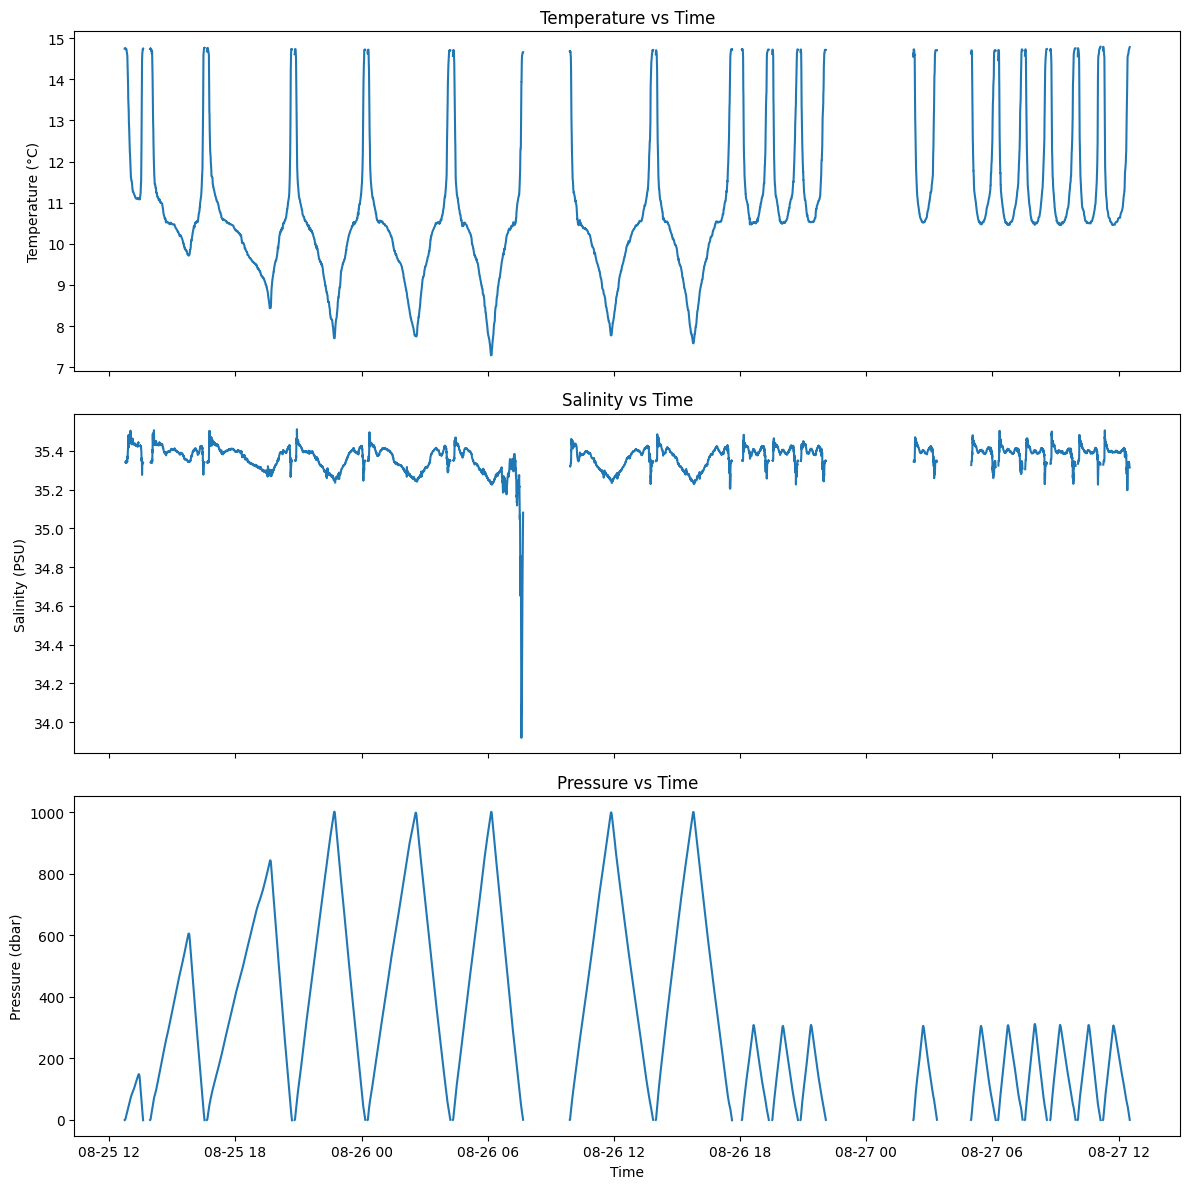

In [24]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Temperature vs Time
axes[0].plot(df["time (UTC)"], df["TEMP (degree_Celsius)"])
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Temperature vs Time")

# Salinity vs Time
axes[1].plot(df["time (UTC)"], df["PSAL (psu)"])
axes[1].set_ylabel("Salinity (PSU)")
axes[1].set_title("Salinity vs Time")

# Pressure vs Time
axes[2].plot(df["time (UTC)"], df["PRES (decibar)"])
axes[2].set_ylabel("Pressure (dbar)")
axes[2].set_xlabel("Time")
axes[2].set_title("Pressure vs Time")

plt.tight_layout()
plt.show()

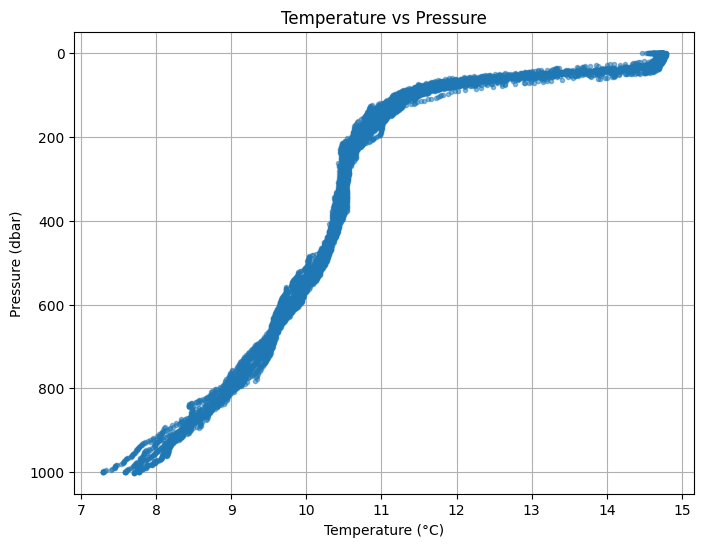

In [25]:
plt.figure(figsize=(8,6))

plt.plot(
    df["TEMP (degree_Celsius)"],
    df["PRES (decibar)"],
    ".",
    alpha=0.5
)

plt.gca().invert_yaxis()

plt.xlabel("Temperature (°C)")
plt.ylabel("Pressure (dbar)")
plt.title("Temperature vs Pressure")

plt.grid(True)
plt.show()

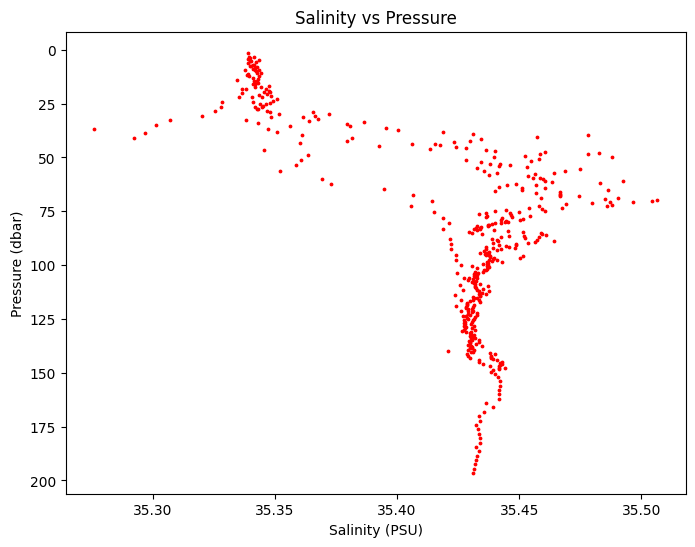

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["PSAL (psu)"][:500],
    df["PRES (decibar)"][:500],
    s=3,
    color="red",
)

plt.gca().invert_yaxis()

plt.xlabel("Salinity (PSU)")
plt.ylabel("Pressure (dbar)")
plt.title("Salinity vs Pressure")

plt.show()